# Multi-Disease Lung Pathology Detection from Chest X-Rays
## Using Deep Learning and Explainable AI
### Notebook 3A — Transfer Learning with ResNet50

**Dataset:** CheXpert v1.0-small — Stanford University ML Group  
**Backbone:** ResNet50 — He et al. (2016). *Deep Residual Learning for Image Recognition.* CVPR. https://doi.org/10.1109/CVPR.2016.90

> All training hyperparameters are **identical** across NB03A, NB03B, and NB03C. The only experimental variable is the CNN backbone architecture, ensuring a fair and scientifically valid comparison.

| Phase | Config | Duration |
|-------|--------|----------|
| 1 — Feature extraction | Backbone frozen, lr=1e-3 | 10 epochs |
| 2 — Fine-tuning | Last 30 layers unfrozen, lr=1e-5 | up to 20 epochs |

---

---
## 1. Environment Setup

In [1]:
import os, warnings, random, json, time, math
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, CSVLogger, LearningRateScheduler
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4

print('TensorFlow:', tf.__version__)
print('GPU       :', tf.config.list_physical_devices('GPU'))

2026-05-17 19:49:10.424371: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779047350.666127      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779047350.724909      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779047351.256099      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779047351.256143      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779047351.256146      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


---
## 2. Configuration

All hyperparameters are **identical** across NB03A, NB03B, and NB03C. The only variable that differs is the CNN backbone architecture.

In [2]:
# ─── Paths (Kaggle) ──────────────────────────────────────────────────────────
BASE_PATH  = '/kaggle/input/datasets/ashery/chexpert'
OUT_DIR    = '/kaggle/working'
MODEL_NAME = 'resnet50'

# ─── Image & batch ────────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32

# ─── Dataset split sizes ──────────────────────────────────────────────────────
TRAIN_SIZE = 50000
VAL_SIZE   = 5000
TEST_SIZE  = 5000

# ─── Training hyperparameters — identical across NB03A, NB03B, NB03C ─────────
EPOCHS_P1        = 10
EPOCHS_P2        = 20
LR_P1            = 1e-3
LR_P2            = 1e-5
ES_PATIENCE      = 8
LABEL_SMOOTH_EPS = 0.05
UNFREEZE_N       = 30  # last 30 of 175 layers (stage 5)

# ─── Labels ───────────────────────────────────────────────────────────────────
LABEL_COLS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]
NUM_CLASSES = len(LABEL_COLS)

print('Model      :', MODEL_NAME)
print('Unfreeze   : last 30 layers (ResNet50 stage 5)')
print('Train size :', TRAIN_SIZE)

Model      : resnet50
Unfreeze   : last 30 layers (ResNet50 stage 5)
Train size : 50000


---
## 3. Load & Prepare Data

**U-Mixed uncertainty strategy:** U-Ones for Edema, Atelectasis, Pleural Effusion, and Cardiomegaly — maximises sensitivity for high-cost missed detections. U-Zeros for all remaining labels.

In [3]:
train_raw = pd.read_csv(os.path.join(BASE_PATH, 'train.csv'))
valid_raw = pd.read_csv(os.path.join(BASE_PATH, 'valid.csv'))

# Frontal views only
train_frontal = train_raw[train_raw['Frontal/Lateral'] == 'Frontal'].copy()

# U-Mixed uncertainty strategy
# U-Ones for clinically critical labels, U-Zeros for the rest
U_ONES = ['Edema', 'Atelectasis', 'Pleural Effusion', 'Cardiomegaly']
for col in LABEL_COLS:
    fill = 1.0 if col in U_ONES else 0.0
    train_frontal[col] = train_frontal[col].fillna(0.0).replace(-1.0, fill).astype(np.float32)
    valid_raw[col]     = valid_raw[col].fillna(0.0).replace(-1.0, fill).astype(np.float32)

# Build full paths
def add_path(df):
    df = df.copy()
    df['full_path'] = df['Path'].str.replace(
        'CheXpert-v1.0-small/', '', regex=False
    ).apply(lambda p: os.path.join(BASE_PATH, p))
    return df

train_frontal = add_path(train_frontal)
gold_df       = add_path(valid_raw)

# Stratified 80/10/10 split — identical across NB03A, NB03B, NB03C
tr_all, tmp = train_test_split(
    train_frontal, test_size=0.20, random_state=SEED,
    stratify=train_frontal['Pleural Effusion']
)
val_all, te_all = train_test_split(
    tmp, test_size=0.50, random_state=SEED,
    stratify=tmp['Pleural Effusion']
)

train_df = tr_all.sample(n=min(TRAIN_SIZE, len(tr_all)), random_state=SEED).reset_index(drop=True)
val_df   = val_all.sample(n=min(VAL_SIZE,  len(val_all)),  random_state=SEED).reset_index(drop=True)
test_df  = te_all.sample(n=min(TEST_SIZE,  len(te_all)),   random_state=SEED).reset_index(drop=True)

# Class weights for imbalanced labels
N = len(train_df)
pos_weights = np.array(
    [(N - train_df[c].sum()) / max(train_df[c].sum(), 1) for c in LABEL_COLS],
    dtype=np.float32
)

print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df), '| Gold:', len(gold_df))
print('Sample path exists:', os.path.exists(train_df['full_path'].iloc[0]))

Train: 50000 | Val: 5000 | Test: 5000 | Gold: 234
Sample path exists: True


---
## 4. tf.data Pipeline

4-operation augmentation pipeline: RandomFlip, RandomRotation, RandomZoom, RandomContrast. `RandomBrightness` excluded — causes GPU sync overhead. Pipeline is identical across NB03A, NB03B, NB03C.

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

# Augmentation: 4 ops — fast, no RandomBrightness which causes slow GPU sync
augment_layer = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom((-0.08, 0.08)),
    layers.RandomContrast(0.10),
], name='augmentation')


def load_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.repeat(img, 3, axis=-1)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def augment_fn(img, label):
    img = augment_layer(tf.expand_dims(img, 0), training=True)[0]
    return tf.clip_by_value(img, 0.0, 1.0), label


def make_ds(df, augment=False, shuffle=False):
    paths  = df['full_path'].values
    labels = df[LABEL_COLS].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(8000, seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_ds(train_df, augment=True,  shuffle=True)
val_ds   = make_ds(val_df,   augment=False, shuffle=False)
test_ds  = make_ds(test_df,  augment=False, shuffle=False)
gold_ds  = make_ds(gold_df,  augment=False, shuffle=False)

print('train_ds:', len(train_df), '->', len(train_df)//BATCH_SIZE, 'batches/epoch')
print('val_ds  :', len(val_df))
print('test_ds :', len(test_df))
print('gold_ds :', len(gold_df))

I0000 00:00:1779047380.534960      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779047380.541152      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


train_ds: 50000 -> 1562 batches/epoch
val_ds  : 5000
test_ds : 5000
gold_ds : 234


---
## 5. Model Architecture — ResNet50

ResNet50 (He et al., 2016) introduced **residual (skip) connections**: each block computes `F(x) + x`, enabling stable gradient flow in very deep networks. 50 weight layers, ~25M parameters, pre-trained on ImageNet.

```
ResNet50 base (ImageNet, frozen in Phase 1)
  └─ GlobalAveragePooling2D
      └─ Dense(512, relu) + BatchNorm + Dropout(0.5)
          └─ Dense(256, relu) + BatchNorm + Dropout(0.3)
              └─ Dense(14, sigmoid)   ← 14 pathologies
```

> Head architecture is **identical** across NB03A, NB03B, NB03C.

In [5]:
def build_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input')
    base = ResNet50(
        include_top=False, weights='imagenet',
        input_tensor=inputs, pooling=None
    )
    base.trainable = False

    x = layers.GlobalAveragePooling2D(name='gap')(base.output)
    x = layers.Dense(512, name='fc1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(0.5, name='drop1')(x)
    x = layers.Dense(256, name='fc2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    out = layers.Dense(NUM_CLASSES, activation='sigmoid', name='predictions')(x)
    return Model(inputs, out, name='ResNet50_CheXpert'), base

model, base_model = build_model()
tr = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
nt = sum(int(np.prod(v.shape)) for v in model.non_trainable_variables)
print('Total params   :', model.count_params())
print('Trainable P1   :', tr, '(head only)')
print('Non-trainable  :', nt, '(frozen backbone)')
print('Backbone layers:', len(base_model.layers))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params   : 24774798
Trainable P1   : 1185550 (head only)
Non-trainable  : 23589252 (frozen backbone)
Backbone layers: 175


---
## 6. Loss Function — Weighted BCE with Label Smoothing

Combines class-weighted binary cross-entropy (corrects label imbalance) with label smoothing ε=0.05 (Szegedy et al., 2016). Identical across all notebooks.

In [6]:
def build_loss(pos_weights, eps=LABEL_SMOOTH_EPS):
    pw  = tf.constant(pos_weights, dtype=tf.float32)
    eps = tf.constant(eps, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        ys = y_true * (1.0 - eps) + 0.5 * eps
        yp = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        return tf.reduce_mean(
            -(pw * ys * tf.math.log(yp) + (1.0 - ys) * tf.math.log(1.0 - yp))
        )
    return loss_fn

loss_fn = build_loss(pos_weights)
print('Loss ready. Label smoothing eps =', LABEL_SMOOTH_EPS)

Loss ready. Label smoothing eps = 0.05


---
## 7. Callbacks

ModelCheckpoint saves best `val_auc`. EarlyStopping patience=8 prevents premature stopping. Phase 2 adds cosine LR annealing (Loshchilov & Hutter, 2017).

In [7]:
CKPT = os.path.join(OUT_DIR, MODEL_NAME + '_best.h5')


def cosine_lr(epoch, lr):
    cos = 0.5 * (1.0 + math.cos(math.pi * epoch / max(EPOCHS_P2 - 1, 1)))
    return float(1e-8 + (LR_P2 - 1e-8) * cos)


def get_callbacks(phase):
    cbs = [
        ModelCheckpoint(CKPT, monitor='val_auc', mode='max',
                        save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_auc', mode='max',
                      patience=ES_PATIENCE, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=3, min_lr=1e-8, verbose=1),
        CSVLogger(os.path.join(OUT_DIR, MODEL_NAME + '_p' + str(phase) + '.csv')),
    ]
    if phase == 2:
        cbs.append(LearningRateScheduler(cosine_lr, verbose=0))
    return cbs

print('Checkpoint:', CKPT)

Checkpoint: /kaggle/working/resnet50_best.h5


---
## 8. Phase 1 — Feature Extraction

Backbone fully frozen. Only the classification head is trained for 10 epochs. Expected: ~1s/step on Kaggle T4.

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(LR_P1), loss=loss_fn,
    metrics=[keras.metrics.AUC(multi_label=True, name='auc'),
             keras.metrics.BinaryAccuracy(name='acc', threshold=0.5)]
)

print('Phase 1 | backbone fully frozen | lr =', LR_P1)
print('Batches/epoch:', len(train_df) // BATCH_SIZE)
t0 = time.time()
h1 = model.fit(train_ds, validation_data=val_ds,
               epochs=EPOCHS_P1, callbacks=get_callbacks(1), verbose=1)
print('P1 done in', round((time.time()-t0)/60, 1), 'min')
print('Best val_auc P1:', round(max(h1.history['val_auc']), 4))

Phase 1 | backbone fully frozen | lr = 0.001
Batches/epoch: 1562
Epoch 1/10


I0000 00:00:1779047393.185210      71 service.cc:152] XLA service 0x7d33a4002340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779047393.185265      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779047393.185271      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779047395.489560      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1563 ━━━━━━━━━━━━━━━━━━━━ 7:09:54 17s/step - acc: 0.4241 - auc: 0.4735 - loss: 1.5406

I0000 00:00:1779047401.947584      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - acc: 0.3794 - auc: 0.5583 - loss: 1.3701
Epoch 1: val_auc improved from -inf to 0.59106, saving model to /kaggle/working/resnet50_best.h5


...

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 378s 242ms/step - acc: 0.3599 - auc: 0.6076 - loss: 1.2867 - val_acc: 0.5601 - val_auc: 0.6043 - val_loss: 1.3643 - learning_rate: 0.0010
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - acc: 0.3566 - auc: 0.6246 - loss: 1.2753
Epoch 3: val_auc improved from 0.60426 to 0.62978, saving model to /kaggle/working/resnet50_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 378s 242ms/step - acc: 0.3566 - auc: 0.6246 - loss: 1.2753 - val_acc: 0.4358 - val_auc: 0.6298 - val_loss: 1.3325 - learning_rate: 0.0010
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - acc: 0.3608 - auc: 0.6337 - loss: 1.2708
Epoch 4: val_auc did not improve from 0.62978
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 378s 242ms/step - acc: 0.3608 - auc: 0.6337 - loss: 1.2708 - val_acc: 0.3981 - val_auc: 0.6174 - val_loss: 1.3264 - learning_rate: 0.0010
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - acc: 0.3594 - auc: 0.6360 - loss: 1.2681
Epoch 5: val_auc improved from 0.62978 to 0.63322, saving model to /kaggle/working/resnet50_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 378s 241ms/step - acc: 0.3594 - auc: 0.6360 - loss: 1.2681 - val_acc: 0.3975 - val_auc: 0.6332 - val_loss: 1.3328 - learning_rate: 0.0010
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - acc: 0.3617 - auc: 0.6433 - loss: 1.2654
Epoch 6: val_auc did not improve from 0.63322
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 378s 241ms/step - acc: 0.3617 - auc: 0.6433 - loss: 1.2654 - val_acc: 0.3937 - val_auc: 0.6256 - val_loss: 1.3138 - learning_rate: 0.0010
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - acc: 0.3617 - auc: 0.6414 - loss: 1.2661
Epoch 7: val_auc improved from 0.63322 to 0.63529, saving model to /kaggle/working/resnet50_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 377s 241ms/step - acc: 0.3617 - auc: 0.6414 - loss: 1.2661 - val_acc: 0.2988 - val_auc: 0.6353 - val_loss: 1.2918 - learning_rate: 0.0010
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - acc: 0.3655 - auc: 0.6471 - loss: 1.2624
Epoch 8: val_auc did not improve from 0.63529
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 377s 241ms/step - acc: 0.3655 - auc: 0.6471 - loss: 1.2624 - val_acc: 0.4140 - val_auc: 0.6340 - val_loss: 1.3520 - learning_rate: 0.0010
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - acc: 0.3643 - auc: 0.6499 - loss: 1.2658
Epoch 9: val_auc did not improve from 0.63529
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 377s 241ms/step - acc: 0.3643 - auc: 0.6499 - loss: 1.2658 - val_acc: 0.3752 - val_auc: 0.6335 - val_loss: 1.2996 - learning_rate: 0.0010
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - acc: 0.3661 - auc: 0.6532 - loss: 1.2615
Epoch 10: val_auc improved from 0.63529 to 0.64421, saving model to /kaggle/working/resnet50_best.h5



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 382s 244ms/step - acc: 0.3661 - auc: 0.6532 - loss: 1.2615 - val_acc: 0.3628 - val_auc: 0.6442 - val_loss: 1.3177 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.
P1 done in 64.4 min
Best val_auc P1: 0.6442


---
## 9. Phase 2 — Fine-Tuning

Last 30 layers of ResNet50 unfrozen — the entirety of stage 5 (res5a, res5b, res5c). These encode the highest-level visual abstractions and benefit most from domain adaptation to chest X-ray features.

| ResNet50 stage | Phase 2 |
|----------------|---------|
| Stage 1–4 | Frozen |
| Stage 5 (last 30 layers) | Unfrozen |

In [9]:
# Unfreeze last 30 layers — ResNet50 stage 5
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

n_frozen   = sum(1 for l in base_model.layers if not l.trainable)
n_unfrozen = sum(1 for l in base_model.layers if l.trainable)
print('Frozen:', n_frozen, '| Unfrozen:', n_unfrozen, '(last 30 layers)')

model.compile(
    optimizer=keras.optimizers.Adam(LR_P2), loss=loss_fn,
    metrics=[keras.metrics.AUC(multi_label=True, name='auc'),
             keras.metrics.BinaryAccuracy(name='acc', threshold=0.5)]
)

t0 = time.time()
h2 = model.fit(train_ds, validation_data=val_ds,
               epochs=EPOCHS_P2, callbacks=get_callbacks(2), verbose=1)
print('P2 done in', round((time.time()-t0)/60,1), 'min')
print('Best val_auc P2:', round(max(h2.history['val_auc']),4))

Frozen: 145 | Unfrozen: 30 (last 30 layers)
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - acc: 0.3558 - auc: 0.6258 - loss: 1.2765
Epoch 1: val_auc improved from -inf to 0.66083, saving model to /kaggle/working/resnet50_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 463s 282ms/step - acc: 0.3558 - auc: 0.6258 - loss: 1.2765 - val_acc: 0.3763 - val_auc: 0.6608 - val_loss: 1.2683 - learning_rate: 1.0000e-05
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - acc: 0.3699 - auc: 0.6562 - loss: 1.2580
Epoch 2: val_auc improved from 0.66083 to 0.66393, saving model to /kaggle/working/resnet50_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 429s 275ms/step - acc: 0.3699 - auc: 0.6562 - loss: 1.2580 - val_acc: 0.3822 - val_auc: 0.6639 - val_loss: 1.2770 - learning_rate: 9.9319e-06
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - acc: 0.3751 - auc: 0.6621 - loss: 1.2573
Epoch 3: val_auc improved from 0.66393 to 0.67304, saving model to /kaggle/working/resnet50_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 426s 272ms/step - acc: 0.3751 - auc: 0.6621 - loss: 1.2573 - val_acc: 0.3853 - val_auc: 0.6730 - val_loss: 1.2550 - learning_rate: 9.7294e-06
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - acc: 0.3778 - auc: 0.6658 - loss: 1.2539
Epoch 4: val_auc improved from 0.67304 to 0.67505, saving model to /kaggle/working/resnet50_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 428s 274ms/step - acc: 0.3778 - auc: 0.6658 - loss: 1.2539 - val_acc: 0.4140 - val_auc: 0.6751 - val_loss: 1.2646 - learning_rate: 9.3980e-06
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - acc: 0.3812 - auc: 0.6687 - loss: 1.2533
Epoch 5: val_auc improved from 0.67505 to 0.67870, saving model to /kaggle/working/resnet50_best.h5


...

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 426s 272ms/step - acc: 0.3944 - auc: 0.6852 - loss: 1.2422 - val_acc: 0.3961 - val_auc: 0.6945 - val_loss: 1.2437 - learning_rate: 3.7788e-06
Epoch 13/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - acc: 0.3951 - auc: 0.6878 - loss: 1.2409
Epoch 13: val_auc did not improve from 0.69446
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 424s 271ms/step - acc: 0.3951 - auc: 0.6878 - loss: 1.2409 - val_acc: 0.4014 - val_auc: 0.6943 - val_loss: 1.2481 - learning_rate: 2.9985e-06
Epoch 14/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - acc: 0.3950 - auc: 0.6877 - loss: 1.2407
Epoch 14: val_auc improved from 0.69446 to 0.69855, saving model to /kaggle/working/resnet50_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 426s 272ms/step - acc: 0.3950 - auc: 0.6877 - loss: 1.2407 - val_acc: 0.3987 - val_auc: 0.6986 - val_loss: 1.2373 - learning_rate: 2.2730e-06
Epoch 15/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - acc: 0.3993 - auc: 0.6883 - loss: 1.2412
Epoch 15: val_auc did not improve from 0.69855
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 423s 271ms/step - acc: 0.3993 - auc: 0.6883 - loss: 1.2412 - val_acc: 0.4173 - val_auc: 0.6953 - val_loss: 1.2427 - learning_rate: 1.6220e-06
Epoch 16/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - acc: 0.3989 - auc: 0.6892 - loss: 1.2392
Epoch 16: val_auc did not improve from 0.69855
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 426s 272ms/step - acc: 0.3989 - auc: 0.6892 - loss: 1.2392 - val_acc: 0.4020 - val_auc: 0.6965 - val_loss: 1.2393 - learning_rate: 1.0632e-06
Epoch 17/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - acc: 0.4001 - auc: 0.6911 - loss: 1.2372
Epoch 17: val_auc did not improve from 0.69855

Epoch 17: ReduceLROnPlateau reducing le

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 426s 273ms/step - acc: 0.4009 - auc: 0.6932 - loss: 1.2373 - val_acc: 0.4069 - val_auc: 0.6987 - val_loss: 1.2367 - learning_rate: 2.8064e-07
Epoch 19/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - acc: 0.4014 - auc: 0.6900 - loss: 1.2372
Epoch 19: val_auc improved from 0.69874 to 0.69880, saving model to /kaggle/working/resnet50_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 431s 276ms/step - acc: 0.4014 - auc: 0.6900 - loss: 1.2372 - val_acc: 0.4045 - val_auc: 0.6988 - val_loss: 1.2375 - learning_rate: 7.8125e-08
Epoch 20/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - acc: 0.4009 - auc: 0.6904 - loss: 1.2400
Epoch 20: val_auc improved from 0.69880 to 0.69899, saving model to /kaggle/working/resnet50_best.h5


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 431s 276ms/step - acc: 0.4009 - auc: 0.6904 - loss: 1.2400 - val_acc: 0.4043 - val_auc: 0.6990 - val_loss: 1.2377 - learning_rate: 1.0000e-08
Restoring model weights from the end of the best epoch: 20.
P2 done in 142.9 min
Best val_auc P2: 0.699


---
## 10. Training Curves

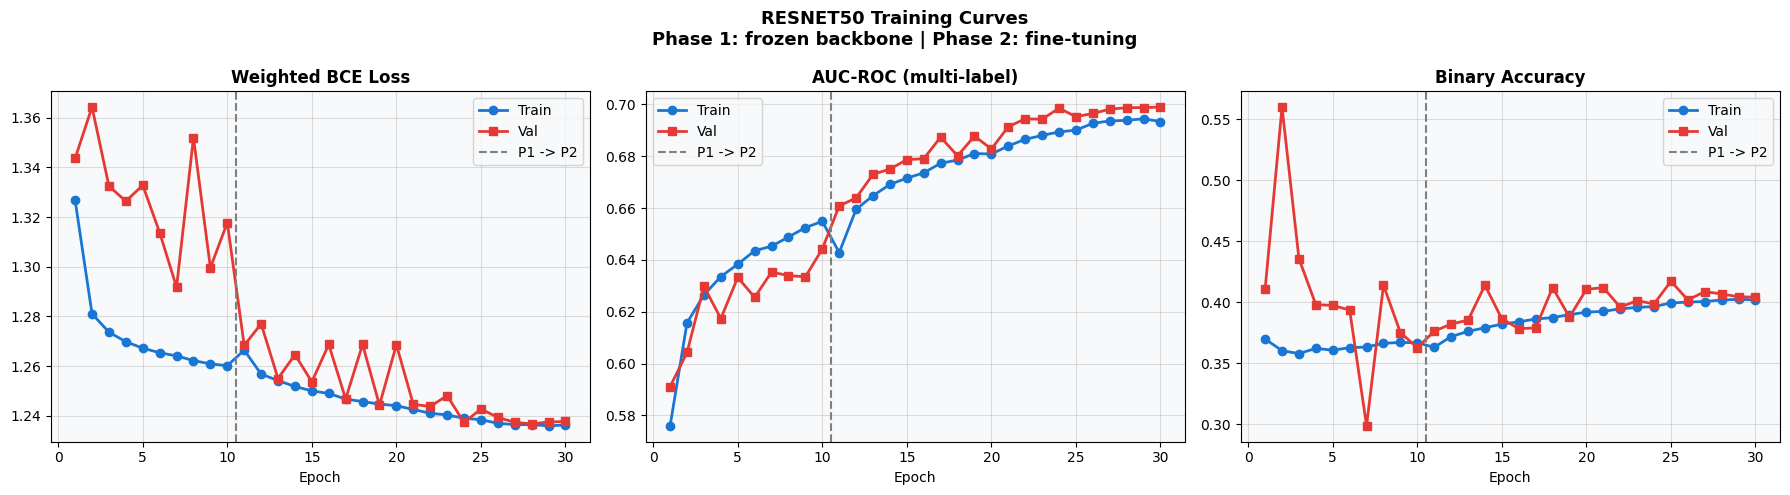

Saved: /kaggle/working/fig_resnet50_curves.png


In [10]:
def merge(h1, h2, k):
    return h1.history.get(k, []) + h2.history.get(k, [])

ep1 = len(h1.history['loss'])
tot = ep1 + len(h2.history['loss'])
x   = list(range(1, tot + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(MODEL_NAME.upper() + ' Training Curves\n'
             'Phase 1: frozen backbone | Phase 2: fine-tuning',
             fontsize=13, fontweight='bold')

for ax, (tk, vk, title) in zip(axes, [
    ('loss', 'val_loss', 'Weighted BCE Loss'),
    ('auc',  'val_auc',  'AUC-ROC (multi-label)'),
    ('acc',  'val_acc',  'Binary Accuracy')
]):
    ax.plot(x, merge(h1, h2, tk), 'o-', color='#1976D2', label='Train', lw=2)
    ax.plot(x, merge(h1, h2, vk), 's-', color='#E53935', label='Val',   lw=2)
    ax.axvline(ep1 + 0.5, color='gray', linestyle='--', lw=1.5, label='P1 -> P2')
    ax.set_xlabel('Epoch'); ax.set_title(title, fontweight='bold'); ax.legend()

plt.tight_layout()
out = os.path.join(OUT_DIR, 'fig_' + MODEL_NAME + '_curves.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show(); print('Saved:', out)

---
## 11. Evaluation — AUC-ROC Per Label

Best checkpoint weights loaded. AUC-ROC computed on test set (N=5,000) and gold set (N=234, radiologist-annotated).

In [11]:
model.load_weights(CKPT)
print('Best weights loaded from:', CKPT)


def predict(ds):
    yt, yp = [], []
    for imgs, labs in ds:
        yt.append(labs.numpy())
        yp.append(model(imgs, training=False).numpy())
    return np.vstack(yt), np.vstack(yp)


def calc_aucs(y_true, y_pred):
    r = {}
    for i, c in enumerate(LABEL_COLS):
        r[c] = float(roc_auc_score(y_true[:,i], y_pred[:,i])) \
               if int(y_true[:,i].sum()) >= 2 else float('nan')
    valid = [v for v in r.values() if not np.isnan(v)]
    r['MEAN_AUC'] = float(np.mean(valid))
    return r


print('Inference on test set...')
yt_test, yp_test = predict(test_ds)
print('Inference on gold set...')
yt_gold, yp_gold = predict(gold_ds)

auc_test = calc_aucs(yt_test, yp_test)
auc_gold = calc_aucs(yt_gold, yp_gold)

print()
print('Pathology'.ljust(35), 'Test AUC'.rjust(10), 'Gold AUC'.rjust(10))
print('-' * 60)
for col in LABEL_COLS:
    t = auc_test.get(col, float('nan'))
    g = auc_gold.get(col, float('nan'))
    print(col.ljust(35),
          ('-' if np.isnan(t) else str(round(t,4))).rjust(10),
          ('-' if np.isnan(g) else str(round(g,4))).rjust(10))
print('-' * 60)
print('MEAN AUC'.ljust(35),
      str(round(auc_test['MEAN_AUC'],4)).rjust(10),
      str(round(auc_gold['MEAN_AUC'],4)).rjust(10))

Best weights loaded from: /kaggle/working/resnet50_best.h5
Inference on test set...
Inference on gold set...

Pathology                             Test AUC   Gold AUC
------------------------------------------------------------
No Finding                              0.8509      0.826
Enlarged Cardiomediastinum               0.615     0.4831
Cardiomegaly                            0.7453     0.7542
Lung Opacity                            0.6679      0.811
Lung Lesion                              0.665          -
Edema                                   0.7582     0.7998
Consolidation                           0.6688      0.825
Pneumonia                               0.6175     0.7013
Atelectasis                             0.6256     0.7077
Pneumothorax                            0.7245     0.6023
Pleural Effusion                        0.7376     0.8002
Pleural Other                           0.6867          -
Fracture                                0.6565          -
Support Devices  

---
## 12. Per-Label AUC Visualisation

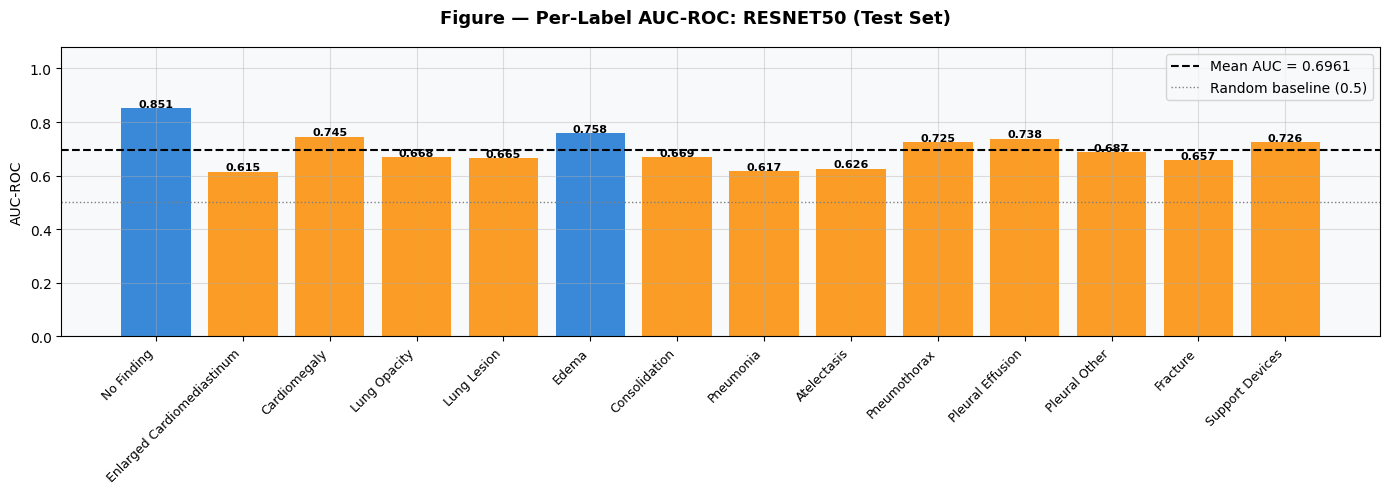

Saved: /kaggle/working/fig_resnet50_auc.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
vals   = [auc_test.get(c, 0.0) for c in LABEL_COLS]
colors = ['#1976D2' if v >= 0.75 else '#FB8C00' if v >= 0.60 else '#E53935'
          for v in vals]
bars = ax.bar(LABEL_COLS, vals, color=colors, alpha=0.85)
ax.axhline(auc_test['MEAN_AUC'], color='black', lw=1.5, linestyle='--',
           label='Mean AUC = ' + str(round(auc_test['MEAN_AUC'], 4)))
ax.axhline(0.5, color='gray', lw=1, linestyle=':', label='Random baseline (0.5)')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            str(round(v,3)), ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(range(len(LABEL_COLS)))
ax.set_xticklabels(LABEL_COLS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('AUC-ROC'); ax.set_ylim(0, 1.08); ax.legend(fontsize=10)
fig.suptitle('Figure — Per-Label AUC-ROC: ' + MODEL_NAME.upper() + ' (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = os.path.join(OUT_DIR, 'fig_' + MODEL_NAME + '_auc.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show(); print('Saved:', out)

---
## 13. Save Results

In [13]:
results = {
    'model': MODEL_NAME,
    'auc_test': {},
    'auc_gold': {},
    'config': {
        'epochs_p1': EPOCHS_P1, 'epochs_p2': EPOCHS_P2,
        'lr_p1': LR_P1, 'lr_p2': LR_P2,
        'es_patience': ES_PATIENCE,
        'label_smooth': LABEL_SMOOTH_EPS,
        'uncertainty': 'U-Mixed',
        'train_n': len(train_df), 'batch': BATCH_SIZE
    }
}

for col in LABEL_COLS + ['MEAN_AUC']:
    v = auc_test.get(col, float('nan'))
    results['auc_test'][col] = None if np.isnan(v) else round(v, 6)
    v = auc_gold.get(col, float('nan'))
    results['auc_gold'][col] = None if np.isnan(v) else round(v, 6)

out_j = os.path.join(OUT_DIR, MODEL_NAME + '_results.json')
with open(out_j, 'w') as f:
    json.dump(results, f, indent=2)

np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ypred_test.npy'), yp_test)
np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ytrue_test.npy'), yt_test)
np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ypred_gold.npy'), yp_gold)
np.save(os.path.join(OUT_DIR, MODEL_NAME + '_ytrue_gold.npy'), yt_gold)

print('Results saved to:', OUT_DIR)
for fname in sorted(os.listdir(OUT_DIR)):
    if MODEL_NAME in fname:
        kb = os.path.getsize(os.path.join(OUT_DIR, fname)) / 1024
        print(' ', fname, round(kb,1), 'KB')

Results saved to: /kaggle/working
  fig_resnet50_auc.png 116.0 KB
  fig_resnet50_curves.png 167.6 KB
  resnet50_best.h5 219564.3 KB
  resnet50_p1.csv 1.4 KB
  resnet50_p2.csv 2.8 KB
  resnet50_results.json 1.1 KB
  resnet50_ypred_gold.npy 12.9 KB
  resnet50_ypred_test.npy 273.6 KB
  resnet50_ytrue_gold.npy 12.9 KB
  resnet50_ytrue_test.npy 273.6 KB


---
## 14. Summary

In [14]:
print('=' * 62)
print('  NOTEBOOK 3A — ResNet50 SUMMARY')
print('=' * 62)
print('  Architecture : ResNet50')
print('  Key property : Residual skip connections')
print('  Head         : GAP -> Dense(512) -> Dense(256) -> Dense(14)')
print()
print('  Training [identical config to all NB03 notebooks]')
print('    P1 :', EPOCHS_P1, 'epochs | backbone frozen | lr =', LR_P1)
print('    P2 : up to', EPOCHS_P2, 'epochs | last 30 layers unfrozen | lr =', LR_P2)
print('    EarlyStopping patience :', ES_PATIENCE)
print('    Label smoothing eps    :', LABEL_SMOOTH_EPS)
print('    Uncertainty strategy   : U-Mixed')
print('    Train N                :', len(train_df))
print()
print('  Results')
print('    Mean AUC (Test) :', round(auc_test['MEAN_AUC'],4))
print('    Mean AUC (Gold) :', round(auc_gold['MEAN_AUC'],4))
best = max([c for c in LABEL_COLS if not np.isnan(auc_test.get(c,float('nan')))],
           key=lambda c: auc_test[c])
print('    Best label      :', best, '=', round(auc_test[best],4))
print('=' * 62)

  NOTEBOOK 3A — ResNet50 SUMMARY
  Architecture : ResNet50
  Key property : Residual skip connections
  Head         : GAP -> Dense(512) -> Dense(256) -> Dense(14)

  Training [identical config to all NB03 notebooks]
    P1 : 10 epochs | backbone frozen | lr = 0.001
    P2 : up to 20 epochs | last 30 layers unfrozen | lr = 1e-05
    EarlyStopping patience : 8
    Label smoothing eps    : 0.05
    Uncertainty strategy   : U-Mixed
    Train N                : 50000

  Results
    Mean AUC (Test) : 0.6961
    Mean AUC (Gold) : 0.7289
    Best label      : No Finding = 0.8509


---

## References

1. He, K., Zhang, X., Ren, S., & Sun, J. (2016). **Deep Residual Learning for Image Recognition.** *CVPR*, 770–778. https://doi.org/10.1109/CVPR.2016.90

2. Irvin, J., et al. (2019). **CheXpert.** *AAAI*, 33(01), 590–597. https://doi.org/10.1609/aaai.v33i01.3301590

3. Rajpurkar, P., et al. (2017). **CheXNet.** *arXiv:1711.05225.*

4. Szegedy, C., et al. (2016). **Label Smoothing.** *CVPR*, 2818–2826.

5. Loshchilov, I., & Hutter, F. (2017). **Cosine Annealing.** *ICLR.* https://arxiv.org/abs/1608.03983